# 🔥 Firestore from Python — A Learning Guide

**Goal:** connect to a Cloud Firestore database with the Firebase Admin SDK, write a few event documents, read them back, and turn them into a chart and a table.

### In a nutshell
This notebook authenticates to Firestore with a **service account key** (a JSON file kept out of git), opens a client, and writes small "agent event" documents into a collection called `agent_logs`. Each document records *what happened* (`eventType`), *who did it* (`userId`), *the payload* (`details`), and *when* — using a server-side timestamp so the clock is Firestore's, not your laptop's. It then queries those documents back in newest-first order, loads them into a pandas `DataFrame`, and finishes with a bar chart of event counts and a readable table. By the end you'll have done a full round trip: **credentials → write → query → analyse**.

### Why Firestore?
Firestore is a **document database**: instead of rows in a fixed-schema table, you store JSON-like documents inside collections. That's a natural fit for logging events from an app or an AI agent, where each record has a slightly different shape. It's also fully managed and real-time — the same data you write here is instantly visible in the Firebase console, and clients can subscribe to changes. The trade-off versus SQL is that you give up joins and ad-hoc aggregation, which is exactly why we pull the documents into pandas at the end.

### Vocabulary
| Term | What it means |
|---|---|
| **Collection** | A named container of documents, e.g. `agent_logs`. Created implicitly by the first write. |
| **Document** | One record: a dict of fields with a unique ID. Max 1 MiB. |
| **Field** | A key/value inside a document. Values can be strings, numbers, maps, arrays, timestamps… |
| **Service account** | A non-human identity. Its JSON key lets server-side code act with admin rights (it bypasses security rules). |
| **Sentinel** | A placeholder value like `SERVER_TIMESTAMP` that the *server* resolves at write time. |

### The pipeline
```
   service account JSON key  (…-firebase-adminsdk-….json)
              │
              ▼
   ┌──────────────────────────────┐        ┌────────────────────────────┐
   │  firebase_admin              │ ─────▶ │  Cloud Firestore           │
   │  initialize_app(cred)        │ ◀───── │  project: firestore-demo   │
   │  firestore.client()   →  db  │        └────────────────────────────┘
   └──────────────────────────────┘
        │                        ▲
        │ WRITE                  │ READ
        │ .collection('agent_logs')      .collection('agent_logs')
        │   .document().set({...})         .order_by('timestamp', DESCENDING)
        │                                  .stream()
        ▼                        │
   ┌──────────────────────────────┐
   │  agent_logs  (collection)    │  doc → eventType · userId · details · timestamp
   └──────────────────────────────┘
              │  list[dict]   (doc.to_dict() per document)
              ▼
   ┌──────────────────────────────┐
   │   pandas DataFrame           │
   └──────────────────────────────┘
              │                  │
              ▼                  ▼
     📊 bar chart (matplotlib)   📋 table (display)
```

Everything you write below also shows up live in the [Firebase console](https://console.firebase.google.com) — keep it open in a second tab.

> Run each cell in order from top to bottom.

## Step 1 — Set up the environment

This project is managed with [uv](https://docs.astral.sh/uv/), and the dependencies are already declared in `pyproject.toml` (`firebase-admin`, `pandas`, `matplotlib`, `ipykernel`). From a terminal in the `firestore-demo/` folder:

```
uv sync
```

Then pick the `firestore-demo` kernel (the project's `.venv`) in the notebook's kernel selector. The cell below is the `pip` equivalent if you'd rather install into whatever environment this kernel is using — leave it commented out when you've already run `uv sync`, and **restart the kernel** after any install.

In [ ]:
# Already ran `uv sync`? Leave this commented out.
# %pip install firebase-admin pandas matplotlib

## Step 2 — Get a service account key

Server-side code doesn't log in as a user — it authenticates as a **service account**. To create one:

1. Open the [Firebase console](https://console.firebase.google.com) → your project → **⚙️ Project settings → Service accounts**.
2. Click **Generate new private key** and save the downloaded JSON next to this notebook.
3. Make sure the filename is in `.gitignore` — it already is here:

```
firestore-demo-e3194-firebase-adminsdk-fbsvc-a8e216154a.json
.venv
```

⚠️ **That key is a full-access credential.** It bypasses Firestore security rules entirely, so anyone holding it can read and write your whole database. Never commit it, never paste it into a notebook cell, and rotate it in the console if it leaks. In production you'd normally skip the file altogether and let Application Default Credentials supply it (`GOOGLE_APPLICATION_CREDENTIALS`, or the metadata server on Cloud Run/Functions).

## Step 3 — Connect to Firestore

Two objects to know:

- **`credentials.Certificate(path)`** loads the key file and proves who you are.
- **`firebase_admin.initialize_app(cred)`** creates the *app* — a process-wide handle. Calling it twice raises `ValueError: The default Firebase app already exists`, which is easy to hit in a notebook where you re-run cells. The `try/get_app()` guard below makes the cell **idempotent**: safe to run as many times as you like.

`firestore.client()` then returns `db`, the entry point for every read and write in this notebook. Nothing has touched the network yet — the first actual round trip happens in Step 4.

In [1]:
import firebase_admin
from firebase_admin import credentials, firestore

SERVICE_ACCOUNT = "firestore-demo-e3194-firebase-adminsdk-fbsvc-a8e216154a.json"

# ---------- Initialise the app (idempotent — safe to re-run) ----------
try:
    app = firebase_admin.get_app()          # already initialised in this kernel?
except ValueError:
    cred = credentials.Certificate(SERVICE_ACCOUNT)
    app = firebase_admin.initialize_app(cred)

# ---------- The Firestore client: our handle for all reads/writes ----------
db = firestore.client()

print("Connected to Firestore successfully. Project:", app.project_id)

Connected to Firestore successfully. Project: firestore-demo-e3194


## Step 4 — Write an event document

Here's the write path, one piece at a time:

- **`db.collection('agent_logs')`** — points at a collection. It doesn't need to exist; Firestore creates it on the first successful write.
- **`.document()`** — with *no argument* this reserves a **new random ID**. Pass a string (`.document('user_123')`) instead when you want a predictable, addressable ID.
- **`.set({...})`** — writes the document, *replacing* it entirely. Related methods worth knowing: `.update({...})` patches individual fields (and fails if the doc doesn't exist), `.set({...}, merge=True)` upserts, and `collection.add({...})` is a one-line shortcut for "auto-ID + set".
- **`firestore.SERVER_TIMESTAMP`** — a **sentinel**. You're not sending a time; you're telling Firestore "fill this in with your own clock when the write lands." That's what makes ordering reliable across machines in different time zones with drifting clocks.

Note that `details` is a plain Python dict — Firestore stores it as a nested **map**, so documents don't all have to share a shape. Run the cell a few times, or change the arguments, to build up more data for the chart later.

In [ ]:
def log_event(event_type: str, user_id: str, details: dict) -> str:
    """Write one event document into `agent_logs` and return its generated ID."""
    doc_ref = db.collection("agent_logs").document()   # no ID given → auto-generated
    doc_ref.set({
        "eventType": event_type,
        "userId": user_id,
        "details": details,
        "timestamp": firestore.SERVER_TIMESTAMP,       # filled in by Firestore's clock
    })
    return doc_ref.id


doc_id = log_event("approve", "user_123", {"action": "Book room for 2 at $100/night"})
print("Event written to Firestore. Document ID:", doc_id)

Event written to Firestore. Document ID: QYsrv6W2bXPmYJ4Ka9UH


## Step 5 — Read the events back

The query is a chain, read top to bottom:

- **`.order_by('timestamp', direction=firestore.Query.DESCENDING)`** sorts newest-first. A single-field sort works out of the box; the moment you combine a `where` filter with an `order_by` on a *different* field, Firestore asks you to create a composite index (the error message contains a link that builds it for you).
- **`.stream()`** executes the query and yields documents lazily, one at a time — better than `.get()` for large result sets, which materialises the whole list. Either way, keep the `.limit()` — a growing collection would otherwise turn into a growing bill.
- **`doc.to_dict()`** converts each `DocumentSnapshot` into a plain Python dict. The `timestamp` comes back as a timezone-aware `datetime`, which we format into a string for display.

The `if data.get('timestamp')` guard matters: a document read back *immediately* after writing can briefly return `None` for a `SERVER_TIMESTAMP` field, because the local write is acknowledged before the server value resolves. If you see `0 event(s)` or a `None` timestamp, just run the cell again.

In [6]:
def fetch_events(limit: int = 50) -> list[dict]:
    """Return `agent_logs` documents, newest first, as a list of plain dicts."""
    docs = (
        db.collection("agent_logs")
        .order_by("timestamp", direction=firestore.Query.DESCENDING)
        .limit(limit)
        .stream()                       # lazy iterator of DocumentSnapshot
    )

    events = []
    for doc in docs:
        data = doc.to_dict()            # snapshot → dict
        data["id"] = doc.id             # keep the document ID alongside the fields
        ts = data.get("timestamp")
        data["timestamp"] = ts.strftime("%Y-%m-%d %H:%M:%S") if ts else None
        events.append(data)
    return events


events_data = fetch_events()
print(f"Loaded {len(events_data)} event(s).")

Loaded 3 event(s).


## Step 6 — Chart the event distribution

Firestore has no `GROUP BY`, so aggregation happens on the client. Once the documents are in a pandas `DataFrame`, `value_counts()` gives us the count per `eventType` and matplotlib draws it.

The `if not df.empty` guard keeps the cell friendly on a fresh, empty database — a pattern worth copying whenever a notebook depends on remote data. With only one event type logged so far you'll get a single bar; go back to Step 4, log a `reject` or a `retry`, and re-run Steps 5–6 to watch the chart fill out.

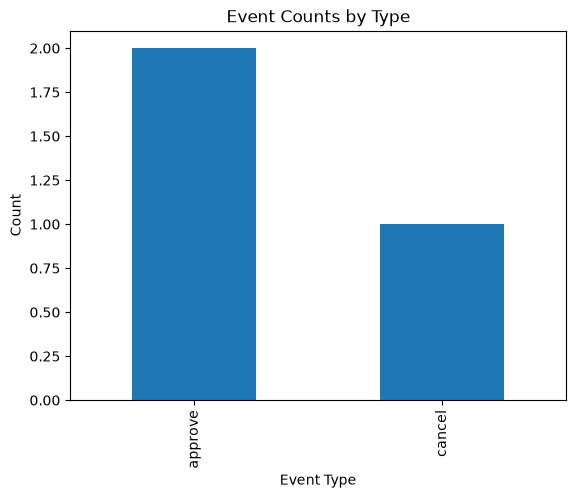

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(events_data)

if not df.empty:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["eventType"].value_counts().plot(kind="bar", title="Event Counts by Type")
    plt.xlabel("Event Type")
    plt.ylabel("Count")
    plt.show()
else:
    print("No events found yet — run Step 4 first.")

## Step 7 — Review the stored records

Finally, the raw documents as a table. `display()` renders the `DataFrame` as HTML rather than the flat text `print()` would give you. Notice the `details` column: each cell holds a **dict**, because Firestore round-tripped the nested map back to Python unchanged.

In [8]:
from IPython.display import display

if not df.empty:
    display(df[["eventType", "userId", "timestamp", "details", "id"]])
else:
    print("No records to display yet.")

,eventType,userId,timestamp,details,id
0,cancel,user_123,2026-07-25 20:50:09,{'action': 'Cancel room reservation'},QYsrv6W2bXPmYJ4Ka9UH
1,approve,user_123,2026-07-25 20:48:57,{'action': 'Book room for 2 at $180/night'},HSmd5GbRstxe9YoS2iC7
2,approve,user_123,2026-07-25 20:30:43,{'action': 'Book room for 2 at $100/night'},Rz2kHxsJDiMS54gCy66z


## 🔎 What to observe in the Firebase console

Open [console.firebase.google.com](https://console.firebase.google.com) → your project → **Build → Firestore Database**. Everything this notebook wrote is there:

- **The `agent_logs` collection**, created by your very first `.set()` — no schema, no migration, no "create table".
- **Auto-generated document IDs** — 20-character random strings. Firestore deliberately makes them non-sequential so writes spread evenly across the key range instead of hammering one shard.
- **Field types.** `details` shows as a **map** you can expand; `timestamp` shows as a **timestamp**, not a string — that's what makes `order_by` meaningful.
- **The server timestamp.** Compare it against your machine's clock: it's Firestore's time, not yours.
- **Live updates.** Leave the console open and re-run Step 4 — the new document appears without a refresh. That same change stream is what powers `on_snapshot()` listeners in a real app.
- **Usage tab.** Reads, writes, and deletes are billed per *document*, not per query. A `.stream()` over 500 documents is 500 reads — the reason `.limit()` in Step 5 isn't just tidiness.
- **Rules tab.** Your service account key ignores these rules completely. Client SDKs (web, iOS, Android) do not — that's the split to keep straight when you move beyond a notebook.

### Try this
1. **Log more event types.** Call `log_event("reject", …)` and `log_event("retry", …)` a few times, then re-run Steps 5–7 to see a real distribution.
2. **Filter server-side.** Query one user's events with the modern filter API:
   ```python
   from google.cloud.firestore_v1.base_query import FieldFilter
   db.collection("agent_logs").where(filter=FieldFilter("userId", "==", "user_123")).stream()
   ```
   Combine it with the `order_by` from Step 5 and Firestore will hand you a link to create the composite index it needs.
3. **Use a named document ID.** Swap `.document()` for `.document("event_001")` and run it twice — the second write *overwrites* rather than appending. Then try `.set({...}, merge=True)` and compare.
4. **Update and delete.** `doc_ref.update({"eventType": "approved"})` patches one field; `doc_ref.delete()` removes the document.
5. **Chart over time.** You already parse `timestamp` into a datetime — try `df.set_index("timestamp").resample("1min").size().plot()` for an events-per-minute view.

### Key takeaways
| Concept | Takeaway |
|---|---|
| Service account | A JSON key authenticates server-side code with **admin rights** — gitignore it, and know that it bypasses security rules. |
| Idempotent init | `initialize_app()` twice raises `ValueError`; guard with `get_app()` so notebook cells stay re-runnable. |
| Collections & documents | Schema-less and created on first write — different documents in one collection can hold different fields. |
| `.document()` vs `.document(id)` | No argument gives a random ID (append); an explicit ID makes the write an overwrite/upsert. |
| `SERVER_TIMESTAMP` | A sentinel resolved by Firestore's clock, so ordering holds across clients — but it may read back as `None` immediately after writing. |
| `.stream()` vs `.get()` | `stream()` yields documents lazily; `get()` materialises the list. Pair either with `.limit()` — billing counts documents read. |
| Aggregation | Firestore has no `GROUP BY`; pull documents into pandas (or use the dedicated count/sum aggregation queries) to summarise. |